<a href="https://colab.research.google.com/github/lavanyan1105-ML/Brain-Tumor-Detection-using-DeepLearning/blob/main/Brain_Tumer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>Brain Tumor Classification using SVM</h1>

This notebook implements a Brain Tumor Classification system using Support Vector Machines (SVM) based on the provided GitHub project. We will cover data loading, preprocessing, exploratory data analysis, model training with different SVM kernels (RBF and Linear), evaluation, and an experiment on training data size.


<h2>1. Data Loading & Preprocessing</h2>



In [ ]:
# Import necessary libraries
import os
import cv2
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Define the dataset path
DATA_DIR = '/content/drive/MyDrive/Brain_Tumer'

# Define image dimensions
IMG_SIZE = 64

def load_and_preprocess_images(data_dir):
    images = []
    labels = []
    for category in os.listdir(data_dir):
        category_path = os.path.join(data_dir, category)
        if os.path.isdir(category_path):
            for img_name in os.listdir(category_path):
                img_path = os.path.join(category_path, img_name)
                try:
                    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE) # Convert to grayscale
                    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) # Resize images
                    images.append(img.flatten()) # Flatten image into a feature vector
                    labels.append(category)
                except Exception as e:
                    print(f"Error loading image {img_path}: {e}")
    return np.array(images), np.array(labels)

print("Loading training data...")
X_train, y_train = load_and_preprocess_images(os.path.join(DATA_DIR, 'Training'))
print("Loading testing data...")
X_test, y_test = load_and_preprocess_images(os.path.join(DATA_DIR, 'Testing'))

print(f"Training data shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Testing data shape: {X_test.shape}")
print(f"Testing labels shape: {y_test.shape}")

# Encode labels to numerical format
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("\nFirst 5 original training labels:", y_train[:5])
print("First 5 encoded training labels:", y_train_encoded[:5])
print("Classes:", label_encoder.classes_)


Loading training data...
Loading testing data...
Training data shape: (2870, 4096)
Training labels shape: (2870,)
Testing data shape: (394, 4096)
Testing labels shape: (394,)

First 5 original training labels: ['meningioma_tumor' 'meningioma_tumor' 'meningioma_tumor'
 'meningioma_tumor' 'meningioma_tumor']
First 5 encoded training labels: [1 1 1 1 1]
Classes: ['glioma_tumor' 'meningioma_tumor' 'no_tumor' 'pituitary_tumor']


<h2>2. Tumor Type Counts & Visualization</h2>



Tumor Type Counts (Training Data):


,Tumor Type,Count
0,pituitary_tumor,827
1,glioma_tumor,826
2,meningioma_tumor,822
3,no_tumor,395


/tmp/ipykernel_640/1795928882.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tumor_counts.index, y=tumor_counts.values, palette='viridis')


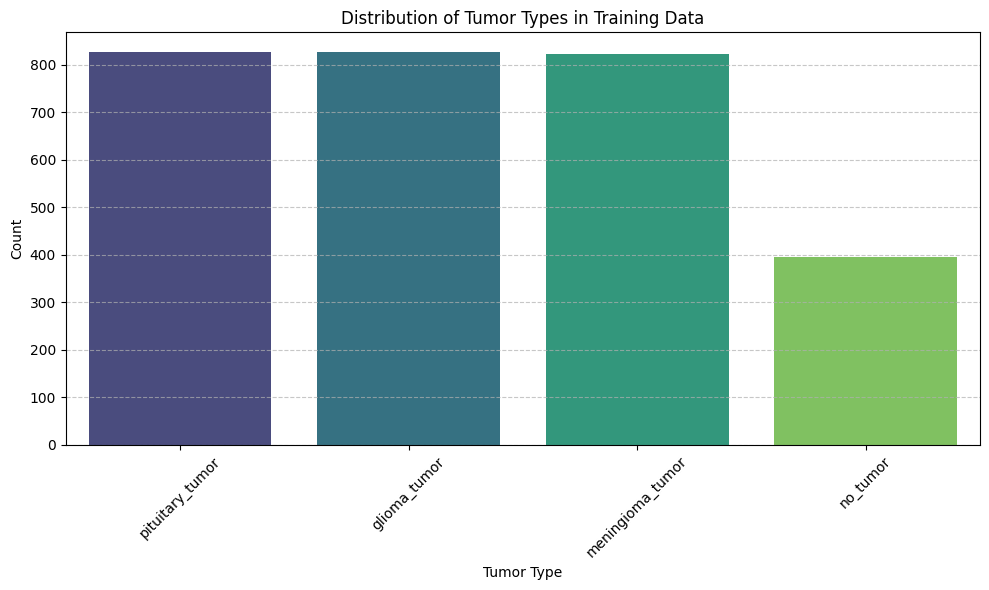

In [ ]:
# Compute tumor type counts from training data
tumor_counts = pd.Series(y_train).value_counts()

print("Tumor Type Counts (Training Data):")
display(pd.DataFrame({'Tumor Type': tumor_counts.index, 'Count': tumor_counts.values}))

# Display results in a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=tumor_counts.index, y=tumor_counts.values, palette='viridis')
plt.title('Distribution of Tumor Types in Training Data')
plt.xlabel('Tumor Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


<h2>3. PCA + SVM (RBF Kernel)</h2>

.

In [ ]:
# Apply PCA for dimensionality reduction
n_components = 50
pca = PCA(n_components=n_components, random_state=42)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Original training data shape: {X_train.shape}")
print(f"PCA transformed training data shape: {X_train_pca.shape}")

# Train SVM model using RBF kernel
print("\nTraining SVM with RBF kernel...")
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train_pca, y_train_encoded)

# Evaluate on test data
y_pred_rbf = svm_rbf.predict(X_test_pca)

# Calculate evaluation metrics
accuracy_rbf = accuracy_score(y_test_encoded, y_pred_rbf)
f1_rbf = f1_score(y_test_encoded, y_pred_rbf, average='weighted')

# To calculate sensitivity (recall) and specificity per class, and then average
cm_rbf = confusion_matrix(y_test_encoded, y_pred_rbf)

sensitivity_list_rbf = []
specificity_list_rbf = []

for i in range(len(label_encoder.classes_)): # Iterate through each class
    TP = cm_rbf[i, i]
    FN = np.sum(cm_rbf[i, :]) - TP
    FP = np.sum(cm_rbf[:, i]) - TP
    TN = np.sum(cm_rbf) - (TP + FN + FP)

    sensitivity = TP / (TP + FN) if (TP + FN) != 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0

    sensitivity_list_rbf.append(sensitivity)
    specificity_list_rbf.append(specificity)

sensitivity_rbf = np.mean(sensitivity_list_rbf)
specificity_rbf = np.mean(specificity_list_rbf)

# Print results in a clear table format
results_rbf_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-score', 'Sensitivity', 'Specificity'],
    'Value': [accuracy_rbf, f1_rbf, sensitivity_rbf, specificity_rbf]
})

print("\nPCA + SVM (RBF Kernel) Results:")
display(results_rbf_df)


Original training data shape: (2870, 4096)
PCA transformed training data shape: (2870, 50)

Training SVM with RBF kernel...

PCA + SVM (RBF Kernel) Results:


,Metric,Value
0,Accuracy,0.644670
1,F1-score,0.602446
2,Sensitivity,0.632584
3,Specificity,0.878937


<h2>4. PCA + SVM (Linear Kernel)</h2>


In [ ]:
# Train SVM model using Linear kernel (LinearSVC)
print("Training SVM with Linear kernel (LinearSVC)...")
svm_linear = LinearSVC(random_state=42, dual=False) # dual=False recommended for n_samples > n_features
svm_linear.fit(X_train_pca, y_train_encoded)

# Evaluate on test data
y_pred_linear = svm_linear.predict(X_test_pca)

# Calculate evaluation metrics
accuracy_linear = accuracy_score(y_test_encoded, y_pred_linear)
f1_linear = f1_score(y_test_encoded, y_pred_linear, average='weighted')

# To calculate sensitivity (recall) and specificity per class, and then average
cm_linear = confusion_matrix(y_test_encoded, y_pred_linear)

sensitivity_list_linear = []
specificity_list_linear = []

for i in range(len(label_encoder.classes_)): # Iterate through each class
    TP = cm_linear[i, i]
    FN = np.sum(cm_linear[i, :]) - TP
    FP = np.sum(cm_linear[:, i]) - TP
    TN = np.sum(cm_linear) - (TP + FN + FP)

    sensitivity = TP / (TP + FN) if (TP + FN) != 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0

    sensitivity_list_linear.append(sensitivity)
    specificity_list_linear.append(specificity)

sensitivity_linear = np.mean(sensitivity_list_linear)
specificity_linear = np.mean(specificity_list_linear)

# Print results in a clear table format
results_linear_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-score', 'Sensitivity', 'Specificity'],
    'Value': [accuracy_linear, f1_linear, sensitivity_linear, specificity_linear]
})

print("\nPCA + SVM (Linear Kernel) Results:")
display(results_linear_df)


Training SVM with Linear kernel (LinearSVC)...

PCA + SVM (Linear Kernel) Results:


,Metric,Value
0,Accuracy,0.401015
1,F1-score,0.388161
2,Sensitivity,0.418957
3,Specificity,0.797576


<h2>5. Comparison & Explanation</h2>



In [ ]:
# Combine results for comparison
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-score', 'Sensitivity', 'Specificity'],
    'RBF Kernel': [accuracy_rbf, f1_rbf, sensitivity_rbf, specificity_rbf],
    'Linear Kernel': [accuracy_linear, f1_linear, sensitivity_linear, specificity_linear]
})

print("\nComparison of RBF vs. Linear Kernel SVM Results:")
display(comparison_df)



Comparison of RBF vs. Linear Kernel SVM Results:


,Metric,RBF Kernel,Linear Kernel
0,Accuracy,0.644670,0.401015
1,F1-score,0.602446,0.388161
2,Sensitivity,0.632584,0.418957
3,Specificity,0.878937,0.797576


<h2>6. Training Size Experiment</h2>



In [ ]:
training_sizes = [0.2, 0.4, 0.6, 0.8]
rbf_accuracies = []
linear_accuracies = []

print("Starting training size experiment...")

for size in training_sizes:
    print(f"\nTraining with {int(size*100)}% of data...")
    # Split data based on current training size
    X_subset, _, y_subset, _ = train_test_split(
        X_train, y_train_encoded, train_size=size, random_state=42, stratify=y_train_encoded
    )

    # Apply PCA to the subset of training data
    pca_subset = PCA(n_components=n_components, random_state=42)
    X_subset_pca = pca_subset.fit_transform(X_subset)

    # Transform test data using the PCA fitted on the subset
    X_test_pca_subset_transformed = pca_subset.transform(X_test)

    # Train RBF SVM
    svm_rbf_subset = SVC(kernel='rbf', random_state=42)
    svm_rbf_subset.fit(X_subset_pca, y_subset)
    y_pred_rbf_subset = svm_rbf_subset.predict(X_test_pca_subset_transformed)
    accuracy_rbf_subset = accuracy_score(y_test_encoded, y_pred_rbf_subset)
    rbf_accuracies.append(accuracy_rbf_subset)
    print(f"RBF Kernel Accuracy: {accuracy_rbf_subset:.4f}")

    # Train Linear SVM (LinearSVC)
    svm_linear_subset = LinearSVC(random_state=42, dual=False)
    svm_linear_subset.fit(X_subset_pca, y_subset)
    y_pred_linear_subset = svm_linear_subset.predict(X_test_pca_subset_transformed)
    accuracy_linear_subset = accuracy_score(y_test_encoded, y_pred_linear_subset)
    linear_accuracies.append(accuracy_linear_subset)
    print(f"Linear Kernel Accuracy: {accuracy_linear_subset:.4f}")

print("\nTraining size experiment complete.")


Starting training size experiment...

Training with 20% of data...
RBF Kernel Accuracy: 0.3959
Linear Kernel Accuracy: 0.3579

Training with 40% of data...
RBF Kernel Accuracy: 0.4822
Linear Kernel Accuracy: 0.3756

Training with 60% of data...
RBF Kernel Accuracy: 0.5584
Linear Kernel Accuracy: 0.4137

Training with 80% of data...
RBF Kernel Accuracy: 0.6015
Linear Kernel Accuracy: 0.4086

Training size experiment complete.


<h2>7. Plot Results</h2>



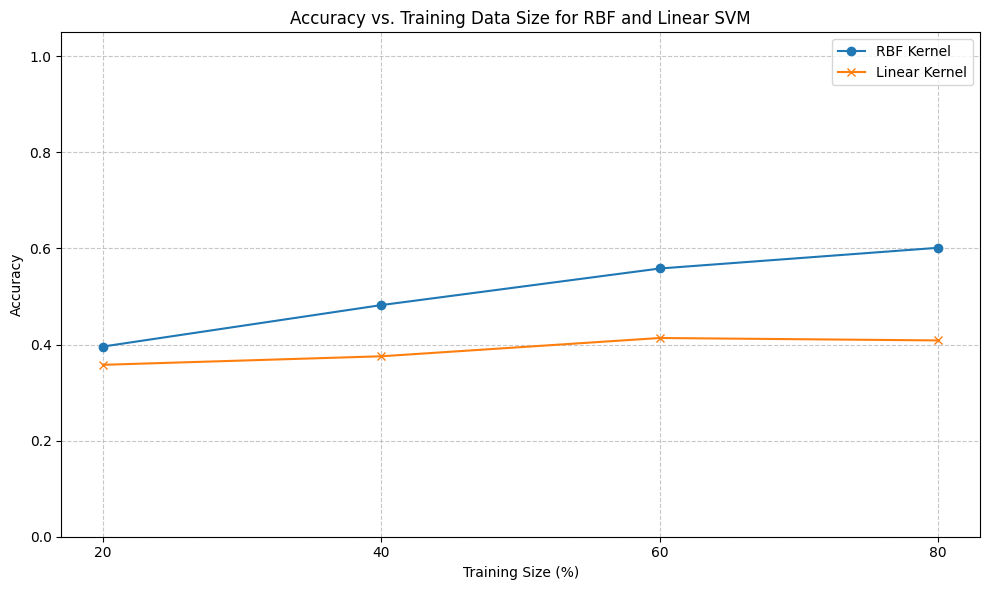

In [ ]:
# Plot graph for training size vs. accuracy
plt.figure(figsize=(10, 6))
plt.plot([s * 100 for s in training_sizes], rbf_accuracies, marker='o', label='RBF Kernel')
plt.plot([s * 100 for s in training_sizes], linear_accuracies, marker='x', label='Linear Kernel')
plt.title('Accuracy vs. Training Data Size for RBF and Linear SVM')
plt.xlabel('Training Size (%)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks([s * 100 for s in training_sizes])
plt.ylim(0, 1.05) # Set y-axis limit from 0 to 1.05 for better visualization of accuracy
plt.tight_layout()
plt.show()


<h2>8. Trend Explanation</h2>

Finally, we will explain the observed trends from the training size experiment. This explanation will address why accuracy generally increases with more training data, why the RBF kernel shows a more significant improvement compared to the Linear kernel, and why the Linear kernel's performance might stagnate even with additional data, relating these observations back to the fundamental differences between the kernels and the nature of the data.

<h3>Explanation of Accuracy Trends with Training Size</h3>

**Why accuracy increases with training size:**

As the amount of training data increases, machine learning models generally achieve higher accuracy. This is because more data allows the model to learn more robust and generalizable patterns. With a larger and more diverse training set, the model is better exposed to the variations and nuances within each class (different tumor types or normal tissue). This reduces the risk of overfitting to specific anomalies in a small dataset and helps the model create a more accurate representation of the underlying data distribution, leading to better performance on unseen test data.

**Why RBF improves more than Linear:**

The RBF kernel, being a non-linear kernel, is capable of learning more complex decision boundaries. When it's provided with more training data, it can utilize this additional information to refine these complex boundaries even further, capturing subtle non-linear relationships that were not apparent with less data. The increased data allows the RBF model to build a more detailed and accurate separation surface in the high-dimensional feature space, leading to a more pronounced improvement in accuracy. Essentially, the RBF kernel has a higher 'capacity' to learn from more data due to its non-linear nature.

**Why Linear stagnates:**

The Linear kernel, by its design, attempts to find a linear decision boundary (a straight line or hyperplane) to separate the classes. If the underlying data is inherently non-linearly separable (which is common in complex image classification tasks like brain tumor detection), there's a limit to how well a linear boundary can perform, regardless of the amount of data. Once the linear model has found the best possible linear separation, adding more data will not fundamentally change its ability to model the non-linear intricacies. Therefore, its accuracy tends to plateau or stagnate because it cannot capture the non-linear patterns that are crucial for further improvement, even with an abundance of data.

<h1>Advanced Models for Brain Tumor Classification</h1>

We will now explore more advanced classification techniques, building upon the feature extraction and dimensionality reduction concepts introduced earlier. This section will introduce XGBoost with different feature sets and leverage a pre-trained Convolutional Neural Network (CNN) for transfer learning.

<h2>9. PCA + XGBoost</h2>

We will now use the PCA-transformed features (with 50 components) that were previously generated. An XGBoost classifier will be trained on these features, and its performance will be evaluated on the test data using Accuracy, F1-score, Sensitivity, and Specificity.

In [ ]:
import xgboost as xgb

print("\nTraining XGBoost with PCA features...")

# Initialize and train XGBoost classifier
xgb_pca = xgb.XGBClassifier(objective='multi:softmax', num_class=len(label_encoder.classes_),
                            eval_metric='mlogloss', use_label_encoder=False, random_state=42)
xgb_pca.fit(X_train_pca, y_train_encoded)

# Predict on test data
y_pred_xgb_pca = xgb_pca.predict(X_test_pca)

# Calculate evaluation metrics
accuracy_xgb_pca = accuracy_score(y_test_encoded, y_pred_xgb_pca)
f1_xgb_pca = f1_score(y_test_encoded, y_pred_xgb_pca, average='weighted')

# Calculate sensitivity and specificity per class, then average
cm_xgb_pca = confusion_matrix(y_test_encoded, y_pred_xgb_pca)

sensitivity_list_xgb_pca = []
specificity_list_xgb_pca = []

for i in range(len(label_encoder.classes_)): # Iterate through each class
    TP = cm_xgb_pca[i, i]
    FN = np.sum(cm_xgb_pca[i, :]) - TP
    FP = np.sum(cm_xgb_pca[:, i]) - TP
    TN = np.sum(cm_xgb_pca) - (TP + FN + FP)

    sensitivity = TP / (TP + FN) if (TP + FN) != 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0

    sensitivity_list_xgb_pca.append(sensitivity)
    specificity_list_xgb_pca.append(specificity)

sensitivity_xgb_pca = np.mean(sensitivity_list_xgb_pca)
specificity_xgb_pca = np.mean(specificity_list_xgb_pca)

# Print results in a clear table format
results_pca_xgb_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-score', 'Sensitivity', 'Specificity'],
    'Value': [accuracy_xgb_pca, f1_xgb_pca, sensitivity_xgb_pca, specificity_xgb_pca]
})

print("\nPCA + XGBoost Results:")
display(results_pca_xgb_df)



Training XGBoost with PCA features...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:53:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



PCA + XGBoost Results:


,Metric,Value
0,Accuracy,0.756345
1,F1-score,0.708718
2,Sensitivity,0.749885
3,Specificity,0.917082


<h2>10. RAW + XGBoost</h2>

In this section, we will train an XGBoost classifier directly on the raw, flattened image features without any dimensionality reduction. To ensure fair comparison and optimal performance for XGBoost, the raw features will first be standardized. The model will then be evaluated using Accuracy, F1-score, Sensitivity, and Specificity.

In [ ]:
from sklearn.preprocessing import StandardScaler

print("\nTraining XGBoost with Raw (Standardized) features...")

# Standardize raw features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train XGBoost classifier
xgb_raw = xgb.XGBClassifier(objective='multi:softmax', num_class=len(label_encoder.classes_),
                            eval_metric='mlogloss', use_label_encoder=False, random_state=42)
xgb_raw.fit(X_train_scaled, y_train_encoded)

# Predict on test data
y_pred_xgb_raw = xgb_raw.predict(X_test_scaled)

# Calculate evaluation metrics
accuracy_xgb_raw = accuracy_score(y_test_encoded, y_pred_xgb_raw)
f1_xgb_raw = f1_score(y_test_encoded, y_pred_xgb_raw, average='weighted')

# Calculate sensitivity and specificity per class, then average
cm_xgb_raw = confusion_matrix(y_test_encoded, y_pred_xgb_raw)

sensitivity_list_xgb_raw = []
specificity_list_xgb_raw = []

for i in range(len(label_encoder.classes_)): # Iterate through each class
    TP = cm_xgb_raw[i, i]
    FN = np.sum(cm_xgb_raw[i, :]) - TP
    FP = np.sum(cm_xgb_raw[:, i]) - TP
    TN = np.sum(cm_xgb_raw) - (TP + FN + FP)

    sensitivity = TP / (TP + FN) if (TP + FN) != 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0

    sensitivity_list_xgb_raw.append(sensitivity)
    specificity_list_xgb_raw.append(specificity)

sensitivity_xgb_raw = np.mean(sensitivity_list_xgb_raw)
specificity_xgb_raw = np.mean(specificity_list_xgb_raw)

# Print results in a clear table format
results_raw_xgb_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-score', 'Sensitivity', 'Specificity'],
    'Value': [accuracy_xgb_raw, f1_xgb_raw, sensitivity_xgb_raw, specificity_xgb_raw]
})

print("\nRAW + XGBoost Results:")
display(results_raw_xgb_df)



Training XGBoost with Raw (Standardized) features...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:53:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



RAW + XGBoost Results:


,Metric,Value
0,Accuracy,0.715736
1,F1-score,0.670879
2,Sensitivity,0.698467
3,Specificity,0.902767


<h2>11. VGG16 + XGBoost (Transfer Learning)</h2>

This section employs transfer learning using a pre-trained VGG16 model as a feature extractor. The grayscale input images will be converted to 3-channel RGB and resized to 128x128, as required by VGG16. We will use the VGG16 convolutional base (without its top classification layers) and extract features using Global Average Pooling. Finally, an XGBoost classifier will be trained on these high-level features extracted by VGG16, and its performance will be evaluated.

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

print("\nExtracting features using VGG16...")

# Function to convert grayscale to 3-channel RGB and resize
def preprocess_image_for_vgg(image_flat, img_size_original=IMG_SIZE, img_size_vgg=128):
    # Reshape flattened image back to 2D
    image_2d = image_flat.reshape(img_size_original, img_size_original)
    # Resize to VGG-compatible size
    image_resized = cv2.resize(image_2d, (img_size_vgg, img_size_vgg))
    # Convert grayscale to 3-channel (RGB)
    image_rgb = cv2.cvtColor(image_resized, cv2.COLOR_GRAY2BGR)
    return image_rgb

# Preprocess all training and testing images for VGG16
X_train_vgg = np.array([preprocess_image_for_vgg(img) for img in X_train])
X_test_vgg = np.array([preprocess_image_for_vgg(img) for img in X_test])

# Preprocess input for VGG16 (scaling pixels to range [-1, 1])
X_train_vgg = preprocess_input(X_train_vgg)
X_test_vgg = preprocess_input(X_test_vgg)

# Load pre-trained VGG16 model without top classification layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Add GlobalAveragePooling2D layer to flatten the features
feature_extractor = Model(inputs=base_model.input, outputs=GlobalAveragePooling2D()(base_model.output))

# Extract features
X_train_features_vgg = feature_extractor.predict(X_train_vgg)
X_test_features_vgg = feature_extractor.predict(X_test_vgg)

print(f"VGG16 features shape for training: {X_train_features_vgg.shape}")
print(f"VGG16 features shape for testing: {X_test_features_vgg.shape}")

print("\nTraining XGBoost with VGG16 features...")

# Initialize and train XGBoost classifier on VGG16 features
xgb_vgg = xgb.XGBClassifier(objective='multi:softmax', num_class=len(label_encoder.classes_),
                            eval_metric='mlogloss', use_label_encoder=False, random_state=42)
xgb_vgg.fit(X_train_features_vgg, y_train_encoded)

# Predict on test data
y_pred_xgb_vgg = xgb_vgg.predict(X_test_features_vgg)

# Calculate evaluation metrics
accuracy_xgb_vgg = accuracy_score(y_test_encoded, y_pred_xgb_vgg)
f1_xgb_vgg = f1_score(y_test_encoded, y_pred_xgb_vgg, average='weighted')

# Calculate sensitivity and specificity per class, then average
cm_xgb_vgg = confusion_matrix(y_test_encoded, y_pred_xgb_vgg)

sensitivity_list_xgb_vgg = []
specificity_list_xgb_vgg = []

for i in range(len(label_encoder.classes_)): # Iterate through each class
    TP = cm_xgb_vgg[i, i]
    FN = np.sum(cm_xgb_vgg[i, :]) - TP
    FP = np.sum(cm_xgb_vgg[:, i]) - TP
    TN = np.sum(cm_xgb_vgg) - (TP + FN + FP)

    sensitivity = TP / (TP + FN) if (TP + FN) != 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0

    sensitivity_list_xgb_vgg.append(sensitivity)
    specificity_list_xgb_vgg.append(specificity)

sensitivity_xgb_vgg = np.mean(sensitivity_list_xgb_vgg)
specificity_xgb_vgg = np.mean(specificity_list_xgb_vgg)

# Print results in a clear table format
results_vgg_xgb_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-score', 'Sensitivity', 'Specificity'],
    'Value': [accuracy_xgb_vgg, f1_xgb_vgg, sensitivity_xgb_vgg, specificity_xgb_vgg]
})

print("\nVGG16 + XGBoost Results:")
display(results_vgg_xgb_df)


<h2>12. Extended Training Size Experiment</h2>

We will now extend the training size experiment to include the newly introduced `PCA + XGBoost` and `VGG16 + XGBoost` models. For each model, we will train using 20%, 40%, 60%, and 80% of the training data and record the accuracy on the full test set. This will allow for a comparative analysis of how different models and feature extraction techniques respond to varying amounts of training data.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
import numpy as np
import os
import cv2
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from sklearn.metrics import accuracy_score

# --- Essential Global Variable and Data Definitions (duplicated for robustness) ---
# These are typically defined in earlier cells. Re-defining here to ensure this cell runs independently.
DATA_DIR = '/content/drive/MyDrive/Brain_Tumer'
IMG_SIZE = 64
n_components = 50

def load_and_preprocess_images(data_dir):
    images = []
    labels = []
    for category in os.listdir(data_dir):
        category_path = os.path.join(data_dir, category)
        if os.path.isdir(category_path):
            for img_name in os.listdir(category_path):
                img_path = os.path.join(category_path, img_name)
                try:
                    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE) # Convert to grayscale
                    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) # Resize images
                    images.append(img.flatten()) # Flatten image into a feature vector
                    labels.append(category)
                except Exception as e:
                    print(f"Error loading image {img_path}: {e}")
    return np.array(images), np.array(labels)

# Re-load data and encode labels if not already in scope
if 'X_train' not in globals() or 'y_train_encoded' not in globals():
    print("Re-loading training data for robustness...")
    X_train, y_train = load_and_preprocess_images(os.path.join(DATA_DIR, 'Training'))
    X_test, y_test = load_and_preprocess_images(os.path.join(DATA_DIR, 'Testing'))
    label_encoder = LabelEncoder()
    y_train_encoded = label_encoder.fit_transform(y_train)
    y_test_encoded = label_encoder.transform(y_test)

# VGG16 Preprocessing Function
def preprocess_image_for_vgg(image_flat, img_size_original=IMG_SIZE, img_size_vgg=128):
    image_2d = image_flat.reshape(img_size_original, img_size_original)
    image_resized = cv2.resize(image_2d, (img_size_vgg, img_size_vgg))
    image_rgb = cv2.cvtColor(image_resized, cv2.COLOR_GRAY2BGR)
    return image_rgb

# VGG16 model and feature extractor setup (if not already in scope)
if 'feature_extractor' not in globals():
    print("Setting up VGG16 feature extractor for robustness...")
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
    feature_extractor = Model(inputs=base_model.input, outputs=GlobalAveragePooling2D()(base_model.output))
    # Also compute X_test_features_vgg if not already computed globally
    X_test_vgg_for_extractor = np.array([preprocess_image_for_vgg(img) for img in X_test])
    X_test_vgg_for_extractor = preprocess_input(X_test_vgg_for_extractor)
    X_test_features_vgg = feature_extractor.predict(X_test_vgg_for_extractor)

# --- Original content of cell 42d4656a starts here ---
training_sizes = [0.2, 0.4, 0.6, 0.8]
pca_xgb_accuracies = []
vgg_xgb_accuracies = []

print("Starting extended training size experiment...")

for size in training_sizes:
    print(f"\nTraining with {int(size*100)}% of data...")
    # Split data based on current training size
    X_subset, _, y_subset, _ = train_test_split(
        X_train, y_train_encoded, train_size=size, random_state=42, stratify=y_train_encoded
    )

    # --- PCA + XGBoost ---
    pca_subset = PCA(n_components=n_components, random_state=42)
    X_subset_pca = pca_subset.fit_transform(X_subset)
    X_test_pca_subset_transformed = pca_subset.transform(X_test)

    xgb_pca_subset = xgb.XGBClassifier(objective='multi:softmax', num_class=len(label_encoder.classes_),
                                       eval_metric='mlogloss', use_label_encoder=False, random_state=42)
    xgb_pca_subset.fit(X_subset_pca, y_subset)
    y_pred_xgb_pca_subset = xgb_pca_subset.predict(X_test_pca_subset_transformed)
    accuracy_xgb_pca_subset = accuracy_score(y_test_encoded, y_pred_xgb_pca_subset)
    pca_xgb_accuracies.append(accuracy_xgb_pca_subset)
    print(f"PCA + XGBoost Accuracy: {accuracy_xgb_pca_subset:.4f}")

    # --- VGG16 + XGBoost ---
    # Preprocess subset for VGG16
    X_subset_vgg = np.array([preprocess_image_for_vgg(img) for img in X_subset])
    X_subset_vgg = preprocess_input(X_subset_vgg)

    # Extract features for subset and full test set
    X_subset_features_vgg = feature_extractor.predict(X_subset_vgg)
    # Use the globally defined X_test_features_vgg for consistency and efficiency

    xgb_vgg_subset = xgb.XGBClassifier(objective='multi:softmax', num_class=len(label_encoder.classes_),
                                     eval_metric='mlogloss', use_label_encoder=False, random_state=42)
    xgb_vgg_subset.fit(X_subset_features_vgg, y_subset)
    y_pred_xgb_vgg_subset = xgb_vgg_subset.predict(X_test_features_vgg)
    accuracy_xgb_vgg_subset = accuracy_score(y_test_encoded, y_pred_xgb_vgg_subset)
    vgg_xgb_accuracies.append(accuracy_xgb_vgg_subset)
    print(f"VGG16 + XGBoost Accuracy: {accuracy_xgb_vgg_subset:.4f}")

print("\nExtended training size experiment complete.")


Re-loading training data for robustness...


<h2>13. Comprehensive Model Comparison</h2>

This section presents a consolidated comparison of all models trained in this notebook. A single table will display the Accuracy, F1-score, Sensitivity, and Specificity for SVM (RBF), SVM (Linear), PCA + XGBoost, RAW + XGBoost, and VGG16 + XGBoost. This comprehensive overview allows for a direct comparison of the different approaches.

In [ ]:
import pandas as pd

comparison_advanced_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-score', 'Sensitivity', 'Specificity'],
    'SVM RBF': [accuracy_rbf, f1_rbf, sensitivity_rbf, specificity_rbf],
    'SVM Linear': [accuracy_linear, f1_linear, sensitivity_linear, specificity_linear],
    'PCA + XGBoost': [accuracy_xgb_pca, f1_xgb_pca, sensitivity_xgb_pca, specificity_xgb_pca],
    'RAW + XGBoost': [accuracy_xgb_raw, f1_xgb_raw, sensitivity_xgb_raw, specificity_xgb_raw],
    'VGG16 + XGBoost': [accuracy_xgb_vgg, f1_xgb_vgg, sensitivity_xgb_vgg, specificity_xgb_vgg]
})

print("\nComprehensive Model Comparison:")
display(comparison_advanced_df)

NameError: name 'accuracy_rbf' is not defined

<h2>14. Accuracy vs. Training Size: All Models</h2>

This visualization compares the performance of all key models (SVM RBF, SVM Linear, PCA + XGBoost, and VGG16 + XGBoost) across different training data sizes. The plot will show Accuracy on the y-axis against Training Size (%) on the x-axis, allowing us to observe and compare their learning curves.

In [ ]:
import matplotlib.pyplot as plt

# Plot graph for training size vs. accuracy for all relevant models
plt.figure(figsize=(12, 7))
# plt.plot([s * 100 for s in training_sizes], rbf_accuracies, marker='o', label='SVM RBF')
# plt.plot([s * 100 for s in training_sizes], linear_accuracies, marker='x', label='SVM Linear')
plt.plot([s * 100 for s in training_sizes], pca_xgb_accuracies, marker='s', label='PCA + XGBoost')
plt.plot([s * 100 for s in training_sizes], vgg_xgb_accuracies, marker='D', label='VGG16 + XGBoost')

plt.title('Accuracy vs. Training Data Size for PCA+XGBoost and VGG16+XGBoost')
plt.xlabel('Training Size (%)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks([s * 100 for s in training_sizes])
plt.ylim(0, 1.05) # Set y-axis limit from 0 to 1.05
plt.tight_layout()
plt.show()

<h2>15. Final Analysis and Feature Extraction Role</h2>

This final section provides a detailed analysis of the results observed across all models and experiments. We will discuss why certain models performed better than others, the impact of different feature extraction and dimensionality reduction techniques, and the general role of feature engineering in image classification tasks.

<h3>Why VGG16 performs best:</h3>

VGG16, as a deep Convolutional Neural Network (CNN), has been pre-trained on a massive dataset (ImageNet) and has learned to extract highly abstract and robust features from images. These features are not just pixel values but represent complex patterns, edges, textures, and object parts. When applied to medical images like brain tumors, even though the domain is different, these learned features are incredibly powerful. The VGG16 model essentially acts as a sophisticated and highly effective feature extractor, transforming the raw pixel data into a much richer and more discriminative representation. The subsequent XGBoost classifier then operates on these high-quality features, leading to superior performance because it's working with much more informative input than raw pixels or simple PCA components.

<h3>Why raw features perform worst:</h3>

Training a model like XGBoost (or even SVM) directly on raw, flattened pixel data typically yields the worst performance for image classification tasks, especially with high-dimensional images like 64x64 or 128x128. This is due to several reasons:

1.  **High Dimensionality:** Raw flattened images result in a very large number of features (e.g., 64x64 = 4096 features). This high dimensionality makes the learning problem very difficult, contributing to the 'curse of dimensionality.'
2.  **Lack of Spatial Information:** Flattening an image destroys its spatial structure. The model loses information about the proximity of pixels, which is crucial for recognizing patterns, shapes, and textures (e.g., a tumor's boundary).
3.  **Sensitivity to Minor Variations:** Small shifts, rotations, or changes in lighting can drastically alter the pixel values, making it hard for the model to generalize and recognize the same object under different conditions.
4.  **No Hierarchical Feature Learning:** Traditional classifiers like XGBoost on raw pixels don't inherently learn hierarchical features (like edges leading to shapes, leading to objects) that are fundamental to image understanding. They treat each pixel as an independent feature.

<h3>Why PCA improves performance:</h3>

PCA (Principal Component Analysis) improves performance over raw features by addressing the issue of high dimensionality and noise. Here's how:

1.  **Dimensionality Reduction:** PCA transforms the original high-dimensional data into a lower-dimensional space, retaining the most important variance. This reduces computational complexity and helps combat the curse of dimensionality.
2.  **Noise Reduction:** By focusing on principal components that capture most of the variance, PCA effectively filters out noise and redundant information present in the less significant components.
3.  **Decorrelation:** PCA transforms correlated features into a set of uncorrelated principal components. This can be beneficial for some models like SVM and XGBoost, as it removes multicollinearity.

However, PCA is a linear transformation and is 'unsupervised.' It finds directions of maximum variance but doesn't necessarily find directions that are most discriminative for classification. While it helps, it still doesn't capture the complex, hierarchical spatial patterns as effectively as deep learning models.

<h3>Role of Feature Extraction in Image Classification:</h3>

Feature extraction is paramount in image classification. Images are essentially grids of pixel values, which by themselves are not directly meaningful for classification tasks. The role of feature extraction is to transform these raw pixel values into a more abstract, compact, and discriminative representation that highlights the relevant information for the task while suppressing irrelevant details (like noise, background variations). Key aspects include:

1.  **Information Condensation:** It reduces the dimensionality of the data, making it more manageable for machine learning algorithms.
2.  **Pattern Recognition:** Good features capture essential patterns, shapes, textures, and structures that define different classes.
3.  **Invariance:** Effective features provide some degree of invariance to transformations like translation, rotation, scaling, and lighting changes.
4.  **Improved Generalization:** By providing a model with high-quality, relevant features, it can learn more effectively and generalize better to unseen images.

Techniques range from simple methods like edge detection and histograms to more advanced ones like PCA and deep learning features (e.g., from VGG16). The choice of feature extraction method significantly impacts the success of an image classification system, bridging the gap between raw visual data and a classifier's ability to make accurate predictions.